# Duckweed Vision Pipeline — Step by Step

Acquire an image from the hardware camera via `MachineSession`, then test each vision ingredient in isolation.

## 1 — Imports

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("../../")
sys.path.append("../")
sys.path.append("../../../")
sys.path.append("../../../../")


from science_jubilee.machine_session import MachineSession
from science_jubilee.Vision.Duckweed_tracker.ingredients.float_detection import get_float_points
from science_jubilee.Vision.Duckweed_tracker.ingredients.segmentation import get_img_contour
from science_jubilee.Vision.Duckweed_tracker.ingredients.isolated_duckweed import detect_isolated_duckweed
from science_jubilee.Vision.Duckweed_tracker.ingredients.pose_estimation import estimate_float_pose
from science_jubilee.Vision.Duckweed_tracker.ingredients.localization import get_lens_position

def show(img, title=""):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

C:\Users\Alienor\Documents\Projects\Jubilee\.pixi\envs\default\Lib\site-packages\sacred\dependencies.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2 — Session + Image Acquisition

Edit `.env.hardware` to point `JUBILEE_EXPERIMENT_DIR` at your experiment folder.

In [9]:
import time

session = MachineSession.from_env(".env.hardware")
cam = session.camera

# move camera to imaging position and capture
X_DEPART, Y_DEPART, Z_DEPART = 220.0, 80.0, 200.0
cam.move_to_get_image(X_DEPART, Y_DEPART, Z_DEPART)


#### Open the camera tab (octoprint) to perform autofocus

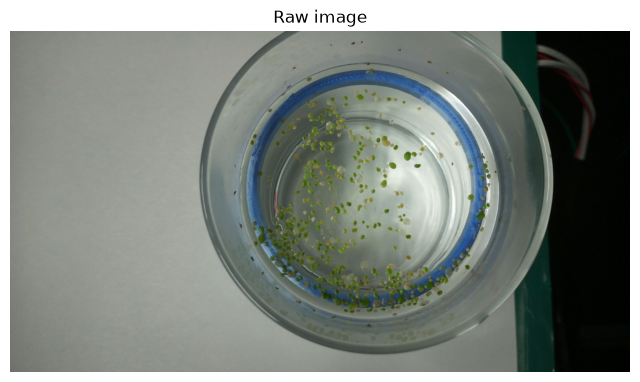

In [10]:

img = cam.get_image()
show(img, "Raw image")

## 3 — Float Detection

Centre (px): (1103, 486)
Radius (px): 370.8887634277344
Cardinal points:
 [[ 732.81665  486.3588 ]
 [1103.7054   115.47003]
 [1474.5942   486.3588 ]
 [1103.7054   857.24756]]


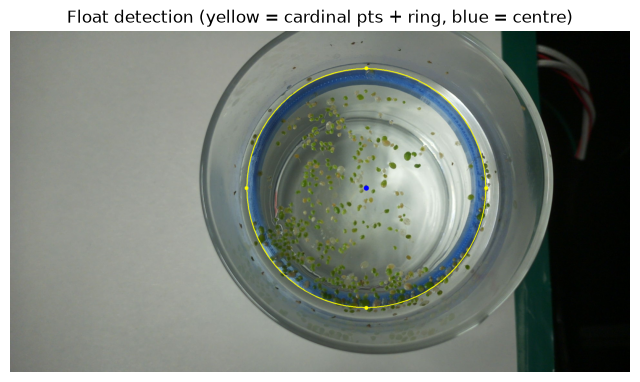

In [11]:
threshold_blue = 170

float_det = get_float_points(img, threshold_blue)
print("Centre (px):", float_det.center_px)
print("Radius (px):", float_det.radius_px)
print("Cardinal points:\n", float_det.points)

vis = img.copy()
for pt in float_det.points:
    cv2.circle(vis, (int(pt[0]), int(pt[1])), 6, (0, 255, 255), -1)
cv2.circle(vis, float_det.center_px, int(float_det.radius_px), (0, 255, 255), 2)
cv2.circle(vis, float_det.center_px, 8, (255, 0, 0), -1)
show(vis, "Float detection (yellow = cardinal pts + ring, blue = centre)")

## 4 — Segmentation (ExG contours)

176 valid contours found


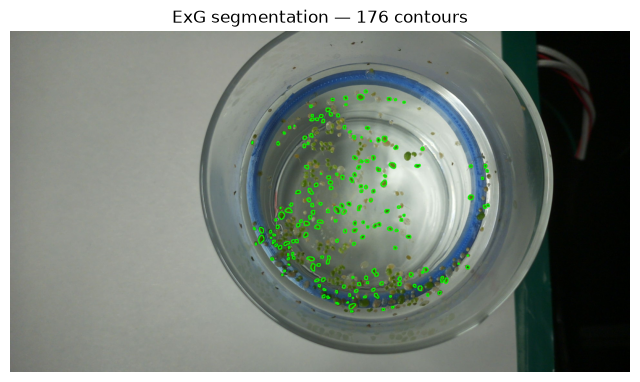

In [12]:
min_area_px=10
max_area_px=300
min_circularity=0.5
threshold_green = 150
contours = get_img_contour(img, min_area_px=min_area_px, max_area_px=max_area_px, min_circularity=min_circularity, threshold_green = threshold_green)
print(f"{len(contours)} valid contours found")

vis = img.copy()
cv2.drawContours(vis, contours, -1, (0, 255, 0), 2)
show(vis, f"ExG segmentation — {len(contours)} contours")

## 5 — Isolated duckweed detection

Target pixel: (1261, 417)


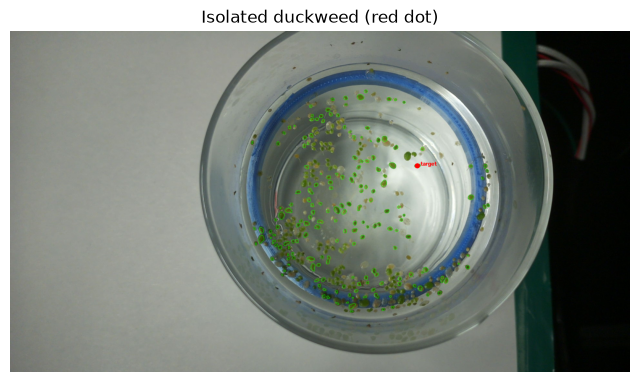

In [13]:
target_px = detect_isolated_duckweed(img, float_points=float_det.points, valid_contours=contours)
print("Target pixel:", target_px)

vis = img.copy()
cv2.drawContours(vis, contours, -1, (0, 255, 0), 1)
if target_px:
    cv2.circle(vis, target_px, 8, (0, 0, 255), -1)
    cv2.putText(vis, "target", (target_px[0]+10, target_px[1]),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
show(vis, "Isolated duckweed (red dot)")

## 6 — Pose estimation (float depth via PnP)

In [15]:
tvec = estimate_float_pose(cam, float_det.points, float_radius_mm = 37.5)
water_level = tvec[2]
print(f"Float 3D (camera frame): X={tvec[0]:.1f}  Y={tvec[1]:.1f}  Z={tvec[2]:.1f} mm")
print(f"Water level (Z): {water_level:.1f} mm")

Float 3D (camera frame): X=14.2  Y=-5.4  Z=148.8 mm
Water level (Z): 148.8 mm


## 7 — 3D localization of the duckweed

In [16]:
if target_px is None:
    print("No target detected — cannot localise.")
else:
    duckweed_3d = get_lens_position(cam, target_px, water_level)
    print(f"Duckweed 3D (camera frame): X={duckweed_3d[0]:.2f}  Y={duckweed_3d[1]:.2f}  Z={duckweed_3d[2]:.2f} mm")

    ox, oy, oz = cam.offset
    x_machine = X_DEPART + ox + duckweed_3d[0]
    y_machine = Y_DEPART + oy - duckweed_3d[1]
    z_machine = Z_DEPART + oz - duckweed_3d[2]
    print(f"Machine frame target: X={x_machine:.2f}  Y={y_machine:.2f}  Z={z_machine:.2f}")

Duckweed 3D (camera frame): X=30.46  Y=-12.27  Z=148.84 mm
Machine frame target: X=250.46  Y=72.27  Z=51.16
